# **Introduction and Problem Statement**
### Customer churn means customers leaving the bank. The goal of this project is to predict whether a customer will leave the bank using machine learning.

# **Dataset Understanding**
The dataset contains customer information such as:

Credit Score ,
Geography ,
Gender ,
Age ,
Balance ,
Salary ,
Exited (Target Variable)

Exited = 1 means customer left the bank.

Exited = 0 means customer stayed.

# **Data Loading**

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df=pd.read_csv('/content/Churn_Modelling.csv')
# Display the first 5 rows of the DataFrame
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# **Data Cleaning and Preparation**

In [22]:
# Display concise summary of the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [23]:
# Drop irrelevant columns: 'RowNumber', 'CustomerId', 'Surname'
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [24]:
# Generate descriptive statistics of the DataFrame
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [25]:
# Check for duplicate rows in the DataFrame
df.duplicated().sum()

np.int64(0)

# **Exploratory Data Analysis (EDA)**

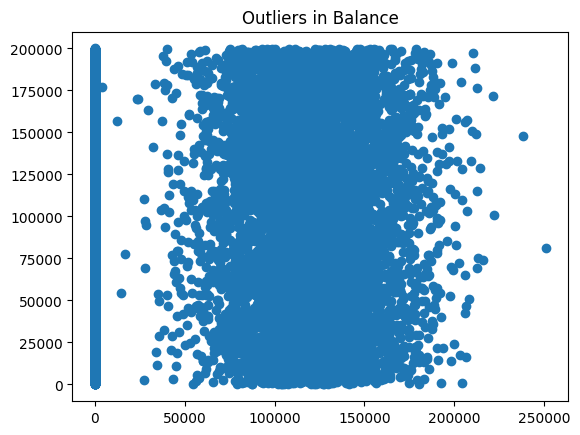

In [26]:
# Create a scatter plot to visualize potential outliers in 'Balance' vs 'EstimatedSalary'
plt.scatter(df['Balance'],df['EstimatedSalary'])
plt.title("Outliers in Balance")
plt.show()

In [27]:
# Create a new feature 'IsZeroBalance' which is 1 if Balance is 0, else 0
df['IsZeroBalance'] = (df['Balance'] == 0).astype(int)

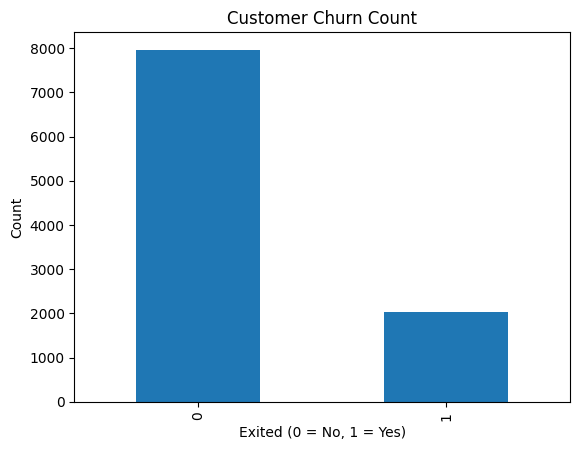

In [28]:
# Plot the count of customers who exited (churned) vs. not exited
df['Exited'].value_counts().plot(kind='bar')

plt.title("Customer Churn Count")
plt.xlabel("Exited (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.show()

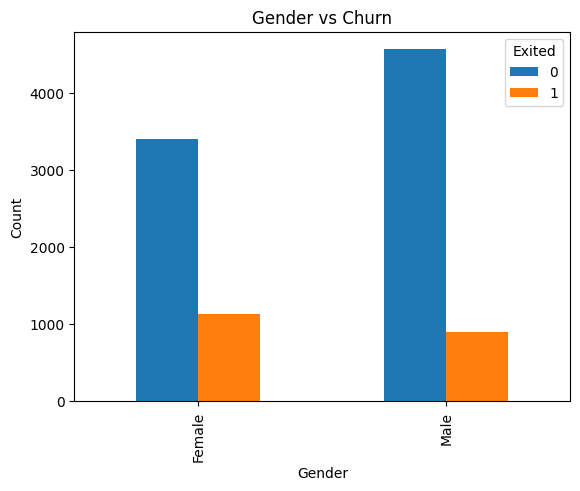

In [29]:
# Create a cross-tabulation of 'Gender' and 'Exited' and plot it as a bar chart
pd.crosstab(df['Gender'], df['Exited']).plot(kind='bar')

plt.title("Gender vs Churn")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

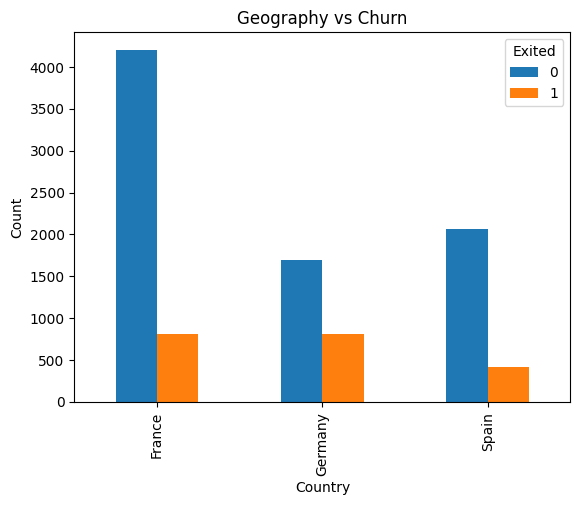

In [30]:
# Create a cross-tabulation of 'Geography' and 'Exited' and plot it as a bar chart
pd.crosstab(df['Geography'], df['Exited']).plot(kind='bar')

plt.title("Geography vs Churn")
plt.xlabel("Country")
plt.ylabel("Count")

plt.show()

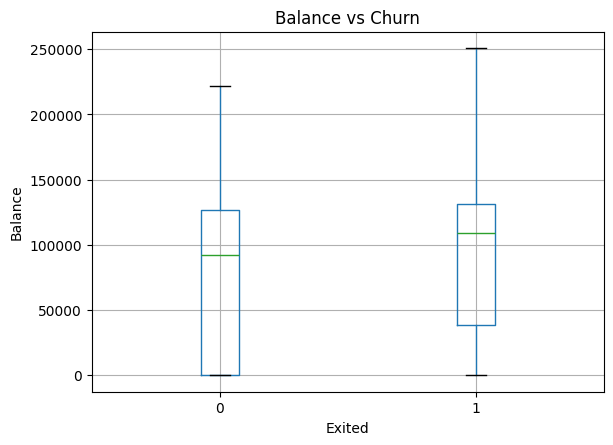

In [31]:
# Create a box plot to visualize the distribution of 'Balance' for customers who exited vs. not exited
df.boxplot(column='Balance', by='Exited')

plt.title("Balance vs Churn")
plt.suptitle("") # Remove default super title
plt.xlabel("Exited")
plt.ylabel("Balance")

plt.show()

In [32]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Apply Label Encoding to the 'Gender' column (Female: 0, Male: 1)
df['Gender'] = le.fit_transform(df['Gender'])

In [33]:
# Apply One-Hot Encoding to the 'Geography' column, dropping the first category to avoid multicollinearity
df = pd.get_dummies(df,columns=['Geography'], drop_first=True)

# **Model Training and Testing**

In [34]:
# Separate features (X) from the target variable (y)
X = df.drop('Exited', axis=1)
y = df['Exited']

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize a RandomForestClassifier model
model = RandomForestClassifier()

# Train the model on the training data
model.fit(X_train, y_train)

RandomForestClassifier()

# **Evaluation Metrics**

In [36]:
from sklearn.metrics import accuracy_score
# Make predictions on the test set
y_pred = model.predict(X_test)
# Calculate and print the accuracy of the model
print("Accuracy:",accuracy_score(y_test, y_pred))

Accuracy: 0.866


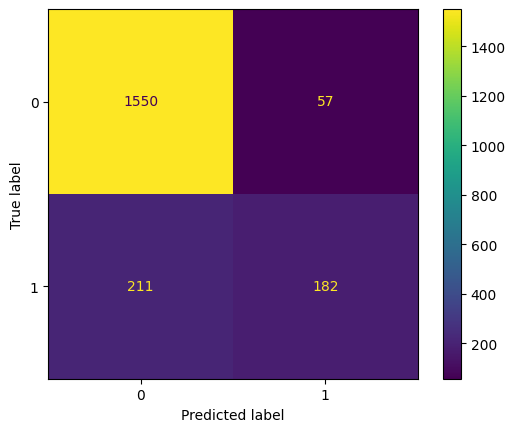

In [37]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Create a ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
# Plot the confusion matrix
disp.plot()
plt.show()

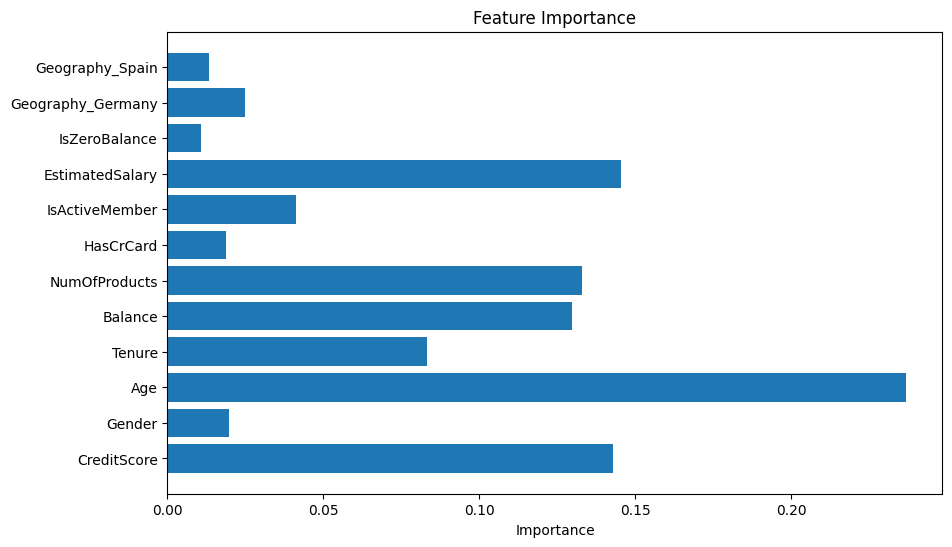

In [38]:
# Get feature importances from the trained RandomForestClassifier model
importance = model.feature_importances_
plt.figure(figsize=(10,6))

# Create a horizontal bar plot of feature importances
plt.barh(X.columns, importance)

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

# **Conclusion**
### The machine learning model successfully predicted customer churn. Important factors affecting churn included:

Age

Balance

Credit Score

Salary

This project helps banks identify customers likely to leave and improve customer retention.